## Exploratory Data Analysis for Climate Trends in Sudan


Importing dependencies

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Data Loading and Date Parsing

**Loading the data and viewing the top rows of the data** 

In [2]:
df = pd.read_csv("sudan.csv")
print(df.shape)
print(df.head())
print(df.info())

(4108, 12)
   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  25.18    35.55    16.14      19.41          0.0  31.87  3.46   
1  2015    2  23.92    34.14    15.81      18.33          0.0  23.83  4.24   
2  2015    3  22.73    31.64    15.09      16.55          0.0  38.21  5.01   
3  2015    4  19.15    27.35    12.88      14.47          0.0  21.07  5.72   
4  2015    5  17.54    27.22     9.49      17.73          0.0  21.58  4.28   

   WS2M_MAX     PS  QV2M  
0      5.12  96.54  6.08  
1      5.10  96.67  4.31  
2      6.24  96.77  6.42  
3      6.96  96.93  3.06  
4      5.82  96.85  2.86  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-null   float64

In [3]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18
4107,2026,90,33.79,42.64,25.73,16.91,0.0,13.89,3.52,5.00,95.89,4.47


**adding country column**

In [4]:
df["country"] = "Sudan"

**Converting YEAR and DOY columns in to datetime column**

In [5]:
df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

**Extracting Month as a separate column**

In [6]:
df["Month"] = df["Date"].dt.month
df[["YEAR", "DOY", "Date", "Month"]].head()

,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


### 2. Summary Statistics & Missing-Value Report

**Replacing all occurrences of -999 with np.nan**

In [7]:
df.replace(-999, np.nan, inplace=True)

**Extracting and droping duplicated rows**

In [8]:
duplicates = df.duplicated().sum()
print(f"There are {duplicates} duplicate rows")

df = df.drop_duplicates()

There are 0 duplicate rows


**Checking duplicates for columns**

In [9]:
for col in df.columns:
    dup_count = df[col].duplicated().sum()
    print(f"{col}: {dup_count} duplicate values")

YEAR: 4096 duplicate values
DOY: 3742 duplicate values
T2M: 2506 duplicate values
T2M_MAX: 2546 duplicate values
T2M_MIN: 2435 duplicate values
T2M_RANGE: 2840 duplicate values
PRECTOTCORR: 3695 duplicate values
RH2M: 1227 duplicate values
WS2M: 3604 duplicate values
WS2M_MAX: 3491 duplicate values
PS: 3953 duplicate values
QV2M: 2747 duplicate values
country: 4107 duplicate values
Date: 0 duplicate values
Month: 4096 duplicate values


**Statistical summary** 

In [10]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


**Interpretation of Statistical summary**
**(YEAR, DOY, Date)**

- DOY ranges from 1 to 366, confirming full yearly coverage including leap years.

- The median date is 2020-08-15, indicating balanced distribution across years.
  
**Tempearture varibales** 

- It range from 13.18°C to 37.99°C with average daily temperature(T2M) 28.76°C,indicating a generally hot climate with occasional cooler periods.

- Maximumtemperature(T2M_MAX) is 45.96°C but Minimum  temperature(T2M_MIN) drops to 5.93°C, howing strong seasonal and daily variability.

- Daily temperature range(T2M_RANGE) has a mean of 15.27°C, with values between 3.42°C and 22.48°C, indicating moderate to high temperature differences.

**PRECTOTCORR/Precipitation** 

- The average daily rainfall is 0.64mm 
- The median value is 0.00 mm, which is much lower than the mean, shows a strong right-skewed distribution
- The maximum value is 66.49mm, indicating rare but very intense rainfall events.

**Relative humidity/ RH2M** 

- The average humidity 31.36%, ranging from 4.69% to 87.16%.
- The median (26.23%) is suggest skewed distribution toward lower humidity levels.
- Dry with occasional humid conditions, indicating an arid to semi-arid climate pattern.

  
**Wind Speed (WS2M, WS2M_MAX)**

- Average wind speed (WS2M) is 3.48 m/s, ranging from 0.61 to 7.15 m/s.
- Maximum wind (WS2M_MAX) reach 9.05 m/s, indicating  strong wind events.
- Wind conditions are moderate overall, with occasional high wind spikes.

**Pressure (PS)**

- Atmospheric pressure is very stable with a mean of 96.35, ranging from 95.66 to 97.31.
- The very low standard deviation (0.27) indicates extremely consistent atmospheric conditions over time.

**Specific Humidity (QV2M)**

- The average specific humidity is 7.86, ranging from 1/16 to 19.44.
- This indicates low to moderate moisture content in the air.

 **Counting missing values, Computing percentage of missing valuees, Listing values with >5%**

In [11]:
count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({
    "Missing Values" : count,
    "percentage (%)": missing_percent,
})

print(missing_report)
high_missing = missing_percent[missing_percent > 5]
if high_missing.empty:
    print("\nNo columns found with >5% missing values.")
else:
    print(f"{high_missing} number of  columns found with >5% missing values.")

             Missing Values  percentage (%)
YEAR                      0             0.0
DOY                       0             0.0
T2M                       0             0.0
T2M_MAX                   0             0.0
T2M_MIN                   0             0.0
T2M_RANGE                 0             0.0
PRECTOTCORR               0             0.0
RH2M                      0             0.0
WS2M                      0             0.0
WS2M_MAX                  0             0.0
PS                        0             0.0
QV2M                      0             0.0
country                   0             0.0
Date                      0             0.0
Month                     0             0.0

No columns found with >5% missing values.


**Missing Value Analysis**

The dataset shows no missing values across all columns and since no column is greater than 5%, no data cleaning required for missing values. It shows higher data quality and  suitable for exploratory data analysis. 

### 3. Outlier Detection & Basic Cleaning

In [12]:
#Selected columns to check for outliers
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

#Calculate Z-scores for each value in the columns
z_scores = stats.zscore(df[cols])

#Flag rows where |Z| > 3
outliers = (np.abs(z_scores) > 3)

#count rows 
outlier_count = outliers.any(axis=1).sum()

print(f"{outlier_count} rows contain outliers")

84 rows contain outliers


**Outlier Analysis**

- *Found*: 84 outliers

- *Observation*: Outliers rows are 84 and 84/4108 ~ 2 % outliers exist

- *Desision*: It should be retain

- *Reasoning*: The extreme values are expected and represent real-world weather conditions.

 **Handling remaining missing values**

In [13]:
row_missing_percent = df.isna().mean(axis=1) * 100
row_missing_percent.head()

df = df[row_missing_percent <= 30]

#applying forward-fill for weather variables

weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

df[weather_cols] = df[weather_cols].ffill()

#dropping rows 
df = df.dropna()

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


Rows with >30% missing data removed, variables forward-filled and remaining missing values were dropped


**Exporting cleaned dataset**

In [14]:
df.to_csv("data/sudan_clean.csv", index=False)

### 4.Time Series Analysis

C:\Users\user\AppData\Local\Temp\ipykernel_16468\2321122583.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df["T2M"].resample("M").mean()


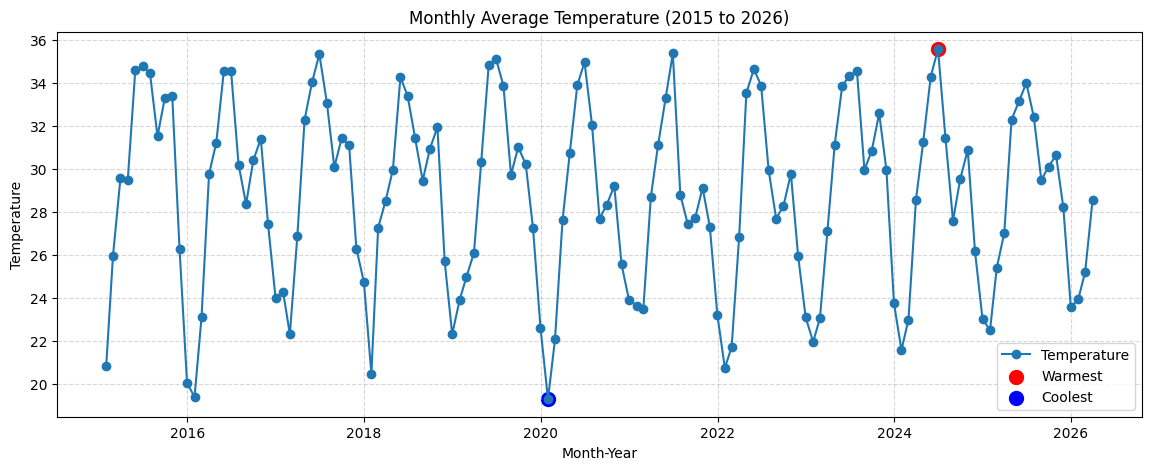

Warmest Month: 2024-06-30 00:00:00
Coolest Month: 2020-01-31 00:00:00


In [15]:
#Plotting monthly Average Temperature

# Convert DATE column to datetime
df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df.set_index("Date", inplace=True)

# Calculate monthly average temperature
monthly_temp = df["T2M"].resample("M").mean()

# Plotting monthly average Temperature
plt.figure(figsize=(14,5))

plt.plot(monthly_temp.index, monthly_temp.values, marker='o', label="Temperature")

# Find warmest and coolest months
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

warmest_value = monthly_temp.max()
coolest_value = monthly_temp.min()

# Highlight points
plt.scatter(warmest_month, warmest_value, color="red", s=100, label="Warmest")
plt.scatter(coolest_month, coolest_value, color="blue", s=100, label="Coolest") 

plt.title("Monthly Average Temperature (2015 to 2026)")
plt.xlabel("Month-Year")
plt.ylabel("Temperature")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

print("Warmest Month:", warmest_month)
print("Coolest Month:", coolest_month)


**Monthly Temperature Analysis**

Seasonality: it shows a clear repeating seasonal pattern, indicating consistent climate cycles over the years.

**Monthly total rainfall**

C:\Users\user\AppData\Local\Temp\ipykernel_16468\1343323091.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rain = df["PRECTOTCORR"].resample("M").sum()


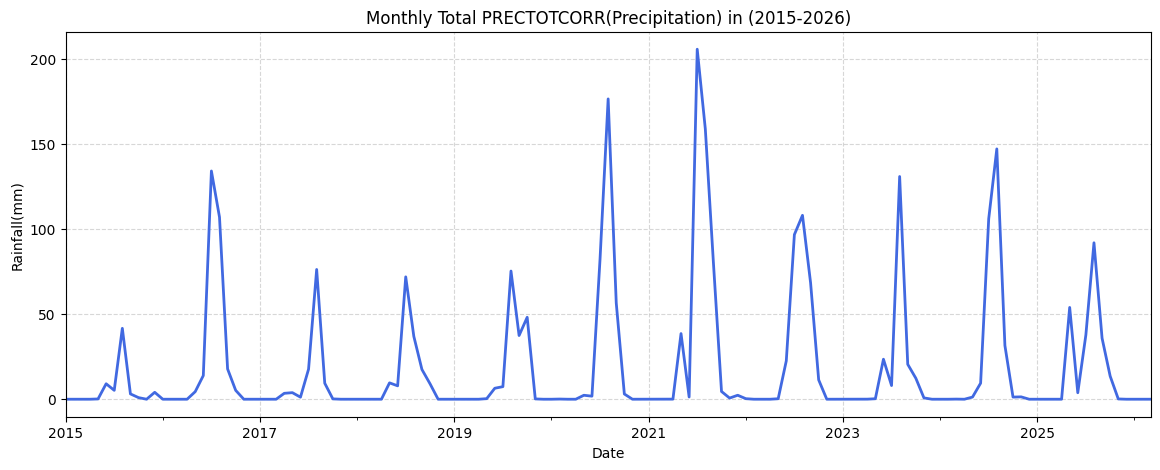

Rainy Months:
 Date
2021-07-31    205.97
2020-08-31    176.73
2021-08-31    159.06
Name: PRECTOTCORR, dtype: float64


In [16]:
#Plotting monthly Total Rainfall

# Convert DATE column to datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df.set_index("Date", inplace=True)

monthly_rain = df["PRECTOTCORR"].resample("M").sum()

plt.figure(figsize=(14,5))

monthly_rain.plot(color='royalblue', linewidth=2)

plt.title("Monthly Total PRECTOTCORR(Precipitation) in (2015-2026)")
plt.xlabel("Date")
plt.ylabel("Rainfall(mm)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#Identifying peak rainy months
top_rain = monthly_rain.sort_values(ascending=False).head(3)
print("Rainy Months:\n", top_rain)

### 5. Correlation and RelationShip Analysis

 Heatmap of correlations across all numeric columns


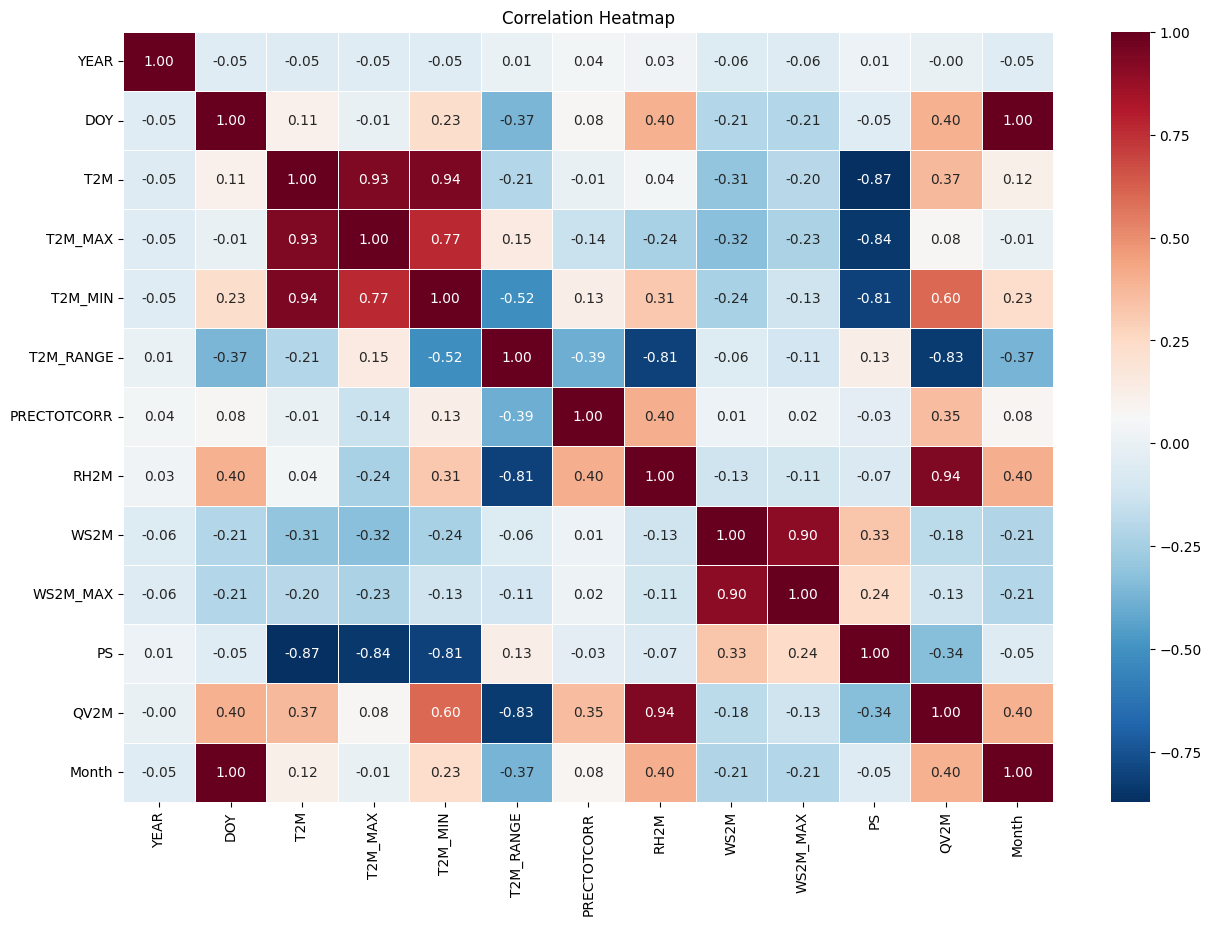

In [17]:
print(" Heatmap of correlations across all numeric columns")
#Select numeric columns
corr = df.select_dtypes(include="number").corr()

# Plotting a heatmap
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, fmt='.2f',  cmap='RdBu_r', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


**Correlation & Relationship Analysis**

- The Darker colors signify strong correlation, while light colors represents weaker correlations.

- Temperature and Humidity have positive correlation and move in same directions. As Temperature increases, humidity also increases. 

- Negative correlation variables move in opposite directions. An increase in one variable is associated with a decrease in the other.

**Scatter Plot 1: T2M vs RH2M**

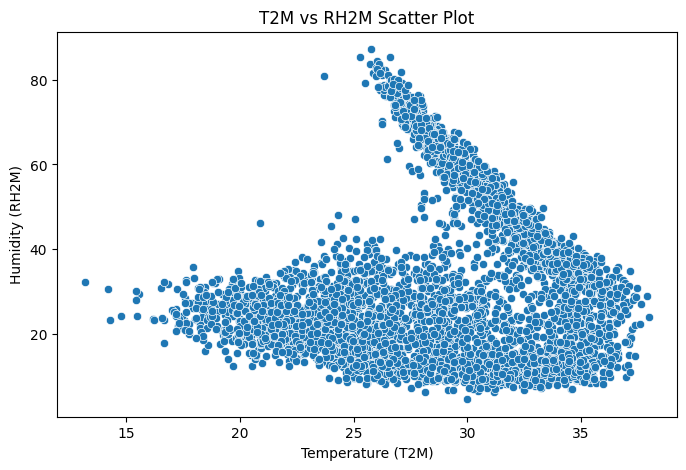

In [18]:
#Scatter plot between Temperature and Humidity
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["T2M"], y=df["RH2M"])

plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")

plt.title("T2M vs RH2M Scatter Plot")
plt.show()

**Scatter Plot 2: T2M_RANGE vs WS2M**

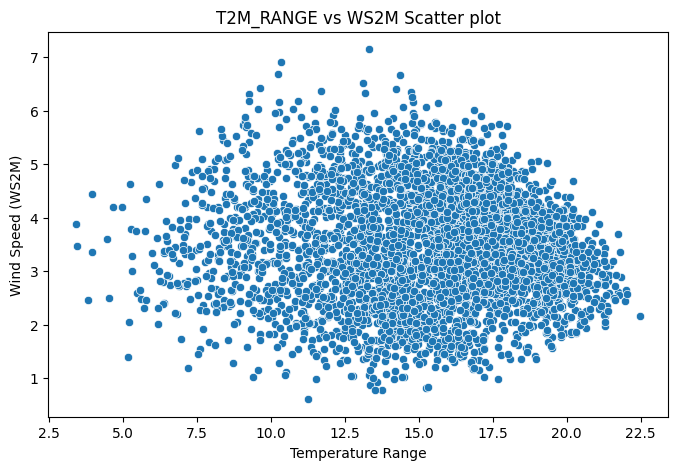

In [19]:
##Scatter plot between Temperature and Humidity

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["T2M_RANGE"], y=df["WS2M"])

plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")

plt.title("T2M_RANGE vs WS2M Scatter plot")
plt.show()

**The strongest correlations**

In [20]:
corr = df.select_dtypes(include="number").corr()

# Convert correlation matrix into pairs
corr_pairs = corr.unstack()

# Remove self-correlation (1.0)
corr_pairs = corr_pairs[corr_pairs != 1]

#remove duplicate pairs
corr_pairs = corr_pairs.drop_duplicates()

# Sort by strongest absolute correlation
strongest = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)


# Top 3 strongest correlations
print(strongest.head(3))

DOY   Month      0.996557
T2M   T2M_MIN    0.941858
RH2M  QV2M       0.935456
dtype: float64


**Strongest Correlations Analysis**

I. DOY vs Month — 0.9966 (Very Strong Positive Correlation)

- This extremely high correlation indicates that Day of Year (DOY) and Month are almost perfectly aligned.
- This is a redundant temporal relationship, not a physical climate interaction, meaning one of the variables may be unnecessary for modeling.

II. T2M vs T2M_MIN — 0.9419

- When daily average temperature increases, the minimum temperature also tends to increase
- This suggests a stable temperature baseline, nights and overall daily conditions warm or cool together consistently.

III. RH2M vs QV2M — 0.9355

- As atmospheric moisture content increases, both humidity measures rise together.


### 6. Distribution Analysis

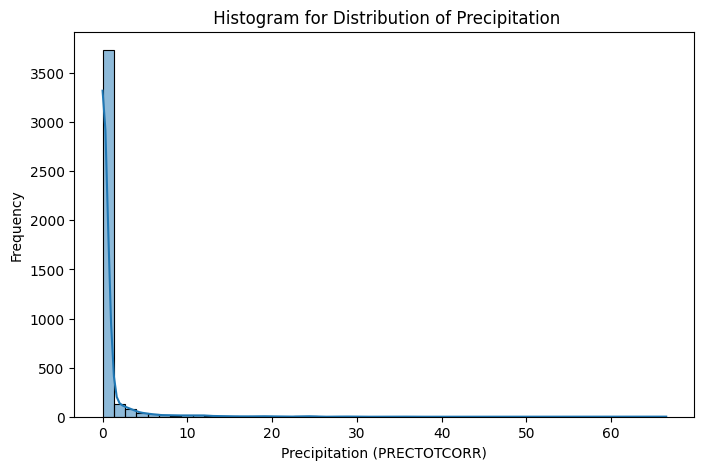

In [21]:
plt.figure(figsize=(8,5))

# Use log scale if data is highly skewed
sns.histplot(df["PRECTOTCORR"], bins=50, kde=True)

plt.xlabel("Precipitation (PRECTOTCORR)")
plt.ylabel("Frequency")
plt.title(" Histogram for Distribution of Precipitation")

plt.show()

**Precipitation Distribution**

- The distribution is highly right-skewed (positively skewed), most values are concentrated near 0 precipitation and a few values extend up to around 60+, but they are rare. 

**Bubble Chart T2M vs RH2M, bubble size = PRECTOTCORR**

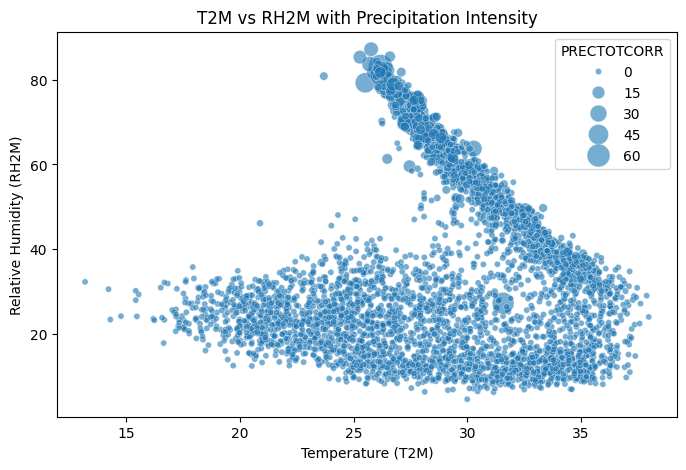

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="T2M",
    y="RH2M",
    size="PRECTOTCORR",
    sizes=(20, 300),
    alpha=0.6,
    legend=True
)

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("T2M vs RH2M with Precipitation Intensity")
plt.show()

**Observation**

- There is a clear negative relationship between temperature and as temperature increases, relative humidity tends to decrease.